EXOPLANET HABITABILITY CLASSIFICATION END-TO-END PROJECT

In [78]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectFromModel

#Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn import tree
from sklearn.naive_bayes import GaussianNB

In [ ]:
df = pd.read_csv("phl_exoplanet_catalog_2019.csv")
df.head()

In [ ]:
df.columns

In [ ]:
shape = df.shape
print(f'Rows: {shape[0]}')
print(f'Columns: {shape[1]}')

In [ ]:
null_vales = df.isnull().sum().sort_values(ascending = False)
null_vales.head(40
                )

In [ ]:
df = df.dropna(["P_DETECTION_MASS", "P_GEO_ALBEDO", "S_MAGNETIC_FIELD", "S_DISC", "P_ATMOSPHERE", "P_ALT_NAMES", "P_DETECTION_RADIUS", "P_GEO_ALBEDO_ERROR_MIN", "P_TEMP_MEASURED", "P_GEO_ALBEDO_ERROR_MAX","P_TPERI_ERROR_MAX", "P_TPERI_ERROR_MIN", "P_TPERI", "P_OMEGA_ERROR_MIN", "P_OMEGA_ERROR_MAX", "P_DENSITY", "P_ESCAPE", "P_POTENTIAL", "P_GRAVITY", "P_OMEGA",   "P_INCLINATION_ERROR_MAX", "P_INCLINATION_ERROR_MIN", "P_INCLINATION", "P_ECCENTRICITY_ERROR_MAX", "P_ECCENTRICITY_ERROR_MIN", "S_TYPE", "P_ECCENTRICITY","P_IMPACT_PARAMETER_ERROR_MIN", "P_IMPACT_PARAMETER_ERROR_MAX", "P_IMPACT_PARAMETER", "P_MASS_ERROR_MAX", "P_MASS_ERROR_MIN", "P_HILL_SPHERE", "P_SEMI_MAJOR_AXIS_ERROR_MIN", "P_SEMI_MAJOR_AXIS_ERROR_MAX", "P_MASS"], axis=1)

In [ ]:
df.info()

In [ ]:
print(df['P_TYPE'])
df['P_TYPE'].isnull().sum()

The “P_TYPE” column in our data describes the exoplanet category and consists of six possible values: Jovian, Superterran, Neptunian, Terran, Subterran, and Miniterran. This feature had 17 missing values.

TO handle the missing values, we can impute them using mode

In [ ]:
df['P_TYPE'] = df['P_TYPE'].fillna(df['P_TYPE'].mode()[0]) #set the first most common value
df['P_TYPE_TEMP'] = df['P_TYPE_TEMP'].fillna(df['P_TYPE_TEMP'].mode()[0])
df['S_TYPE_TEMP'] = df['S_TYPE_TEMP'].fillna(df['S_TYPE_TEMP'].mode()[0]) 

nOw WE HANDLED MISSING VALUES IN CATEGORICAL DATA, NO WE WILL WORK UPON NUMERICAL DATA 

We are going to use Scikit-learn's imputer because it provides a systematic way to replace missing numerical data, and IterativeImputer is particularly useful when we want to use relationships between multiple features to make those replacements.


In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

# Impute only numeric columns
imp = IterativeImputer(max_iter=10, verbose=0)
df[numeric_cols] = imp.fit_transform(df[numeric_cols])

we have corrected all of our missing values! But, we still have a major class imbalance to work with. Since we don’t know of many potentially habitable planets, the number of inhabitable exoplanets greatly outnumbers the habitable ones. This will likely cause our model to guess an exoplanet is inhabitable, even if it’s not the case, because it will still have an average of like 99% accuracy. Thus, we need to find a way to balance the scales.

We will use upsampling method, using algorithm SMOTE.

In [ ]:
X= df.iloc[:, df.columns != 'P_HABITABLE']
y = df['P_HABITABLE']
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_res, y_res = smote.fit_resample(X,y)

df = pd.concat([pd.DataFrame(X_res), pd.DataFrame(y_res)], axis = 1 )
df.head()

After balancing the data, we can now move to visualize the data

First we will visualise it using a correlation heatmap as the model might learn correlations that aren’t really related to the actual habitability of the planet.

<Axes: >

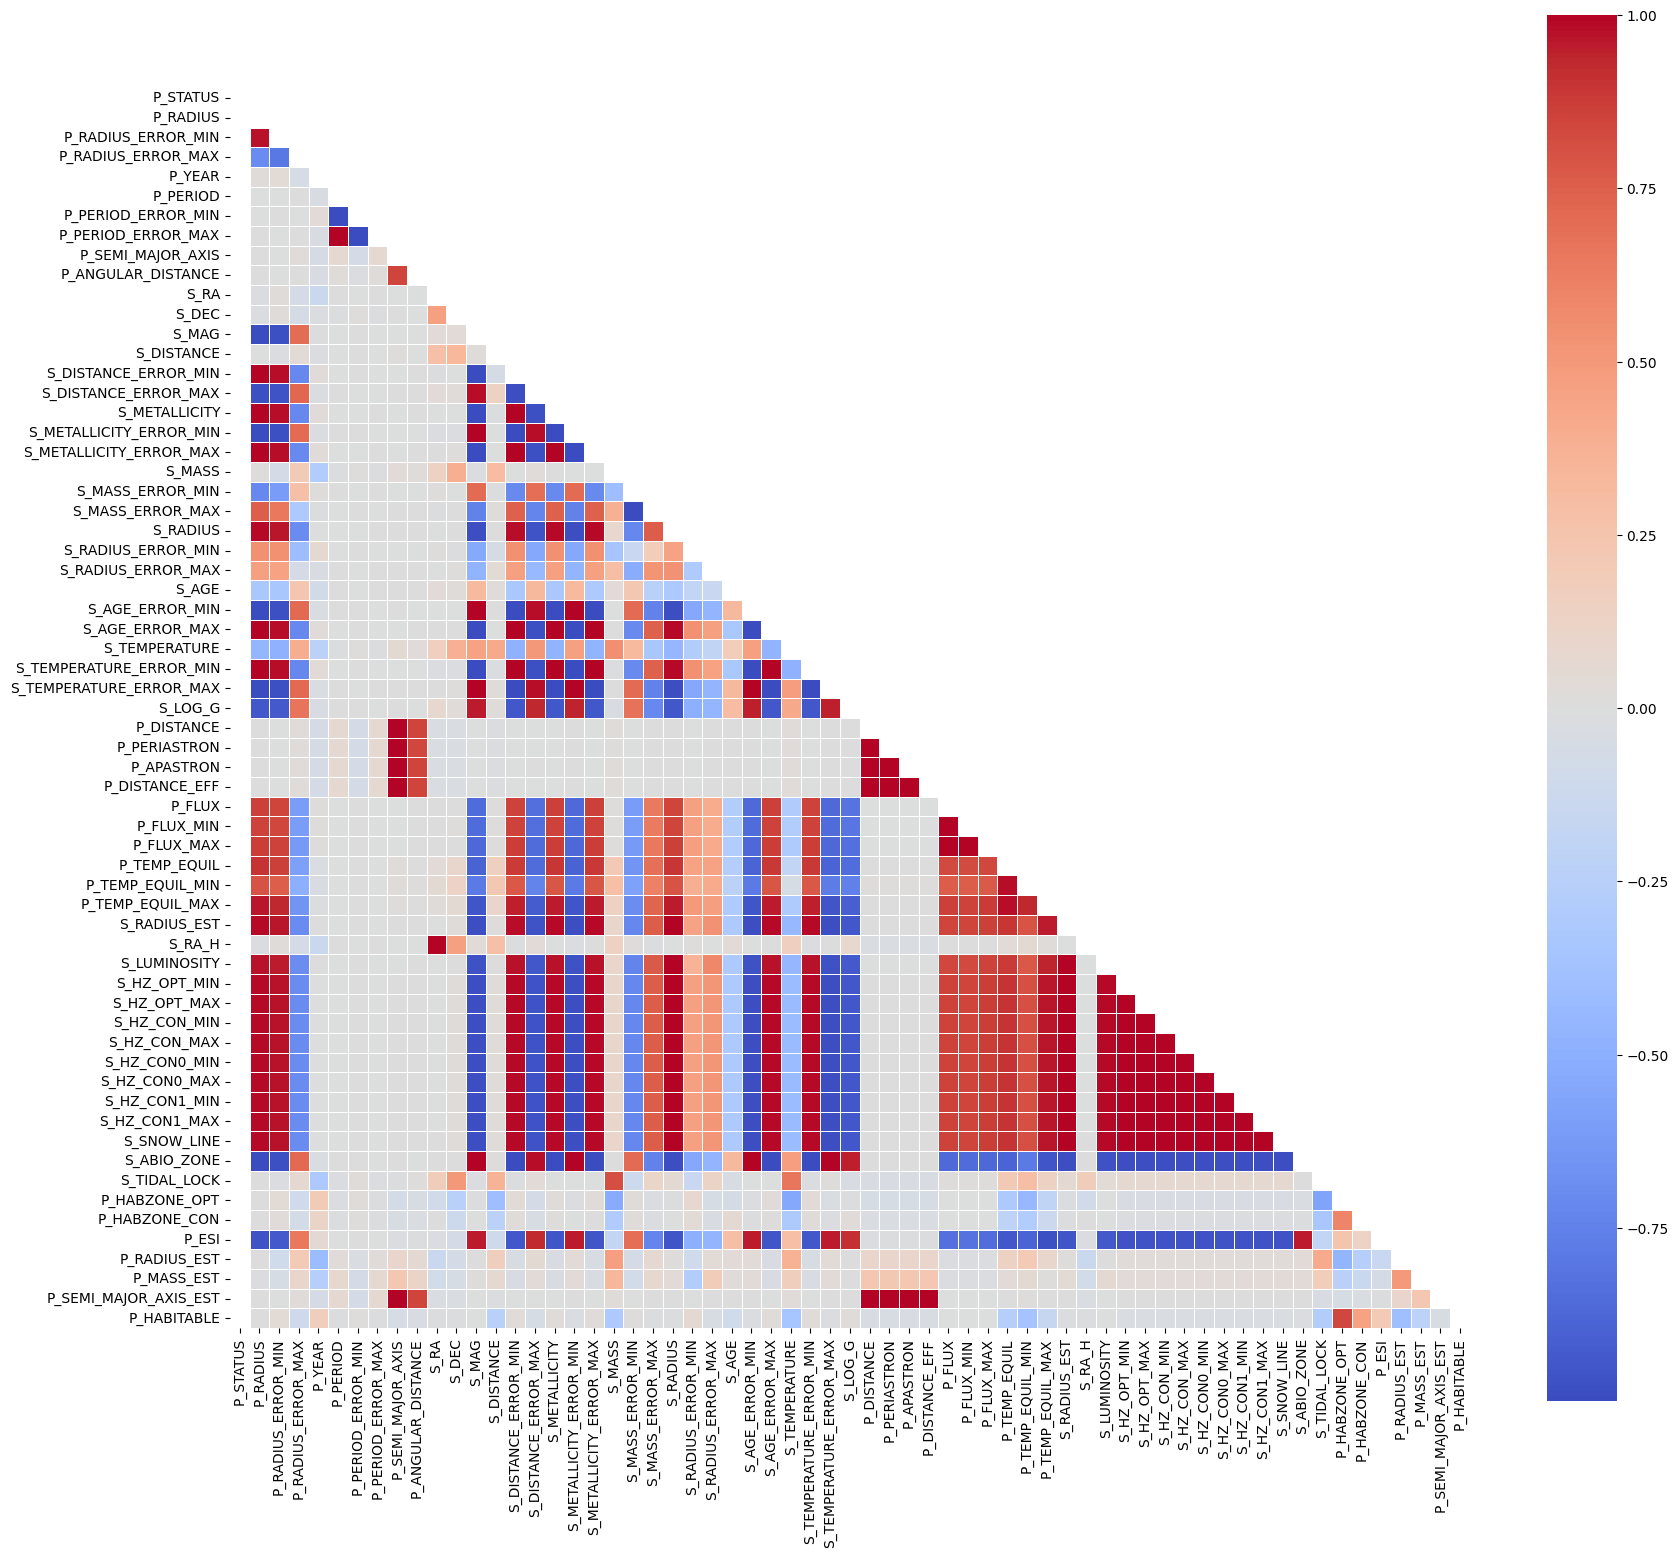

In [88]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))
f,ax = plt.subplots(figsize=(20,20))

sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,annot=False, linewidths=.5, cbar_kws={"shrink": 0.9})

The dark red squares indicate that the two corresponding variables are highly related to one another and might cause unwanted connections in our machine learning model.

In [ ]:
working_data = df.drop([ 'P_RADIUS', 'P_RADIUS_ERROR_MIN', 'P_RADIUS_ERROR_MAX', 'P_DISTANCE', 'P_PERIASTRON', 'P_APASTRON', 'P_DISTANCE_EFF', 'P_FLUX_MIN', 'P_FLUX_MAX', 'P_TEMP_EQUIL', 'P_TEMP_EQUIL_MIN', 'P_TEMP_EQUIL_MAX', 'S_RADIUS_EST', 'S_RA_H', 'S_RA_T', 'S_LUMINOSITY', 'S_HZ_OPT_MIN', 'S_HZ_OPT_MAX', 'S_HZ_CON_MIN', 'S_HZ_CON_MAX', 'S_HZ_CON0_MIN', 'S_HZ_CON0_MAX', 'S_HZ_CON1_MIN', 'S_HZ_CON1_MAX', 'S_SNOW_LINE', 'P_PERIOD_ERROR_MIN', 'P_PERIOD_ERROR_MAX', 'S_MAG', 'S_DISTANCE_ERROR_MIN', 'S_DISTANCE_ERROR_MAX', 'S_METALLICITY', 'S_METALLICITY_ERROR_MIN', 'S_METALLICITY_ERROR_MAX', 'S_AGE', 'S_TEMPERATURE_ERROR_MIN', 'S_TEMPERATURE_ERROR_MAX', 'S_ABIO_ZONE', 'P_ESI', 'S_CONSTELLATION_ABR', 'P_SEMI_MAJOR_AXIS_EST'], axis=1)